In [1]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.columns)
print(df['Machine failure'].value_counts(normalize=True))
df.head()

(10000, 14)
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
drop_cols = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df = df.drop(columns=drop_cols)
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')


In [3]:
df.isnull().sum()

,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0


In [5]:
df = pd.get_dummies(df, columns=['Type'])
print(df.columns)

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Type_H', 'Type_L', 'Type_M'],
      dtype='object')


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Machine failure'])
y = df['Machine failure']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

cols_to_scale = ['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
scaler = StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_s[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)
logreg_pred = logreg.predict(X_test_s)
logreg_proba = logreg.predict_proba(X_test_s)[:,1]

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)
rf_proba = rf.predict_proba(X_test_s)[:,1]

accuracy: 0.9675
              precision    recall  f1-score   support

           0     0.9693    0.9979    0.9834      1932
           1     0.6364    0.1029    0.1772        68

    accuracy                         0.9675      2000
   macro avg     0.8028    0.5504    0.5803      2000
weighted avg     0.9580    0.9675    0.9560      2000

average precision score: 0.4205369579251732
precision-recall curve:


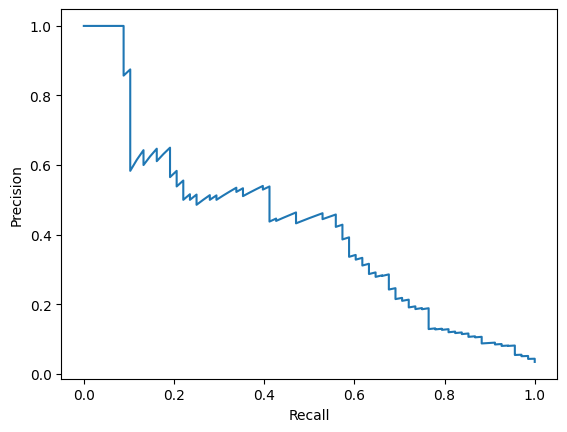

accuracy: 0.9805
              precision    recall  f1-score   support

           0     0.9822    0.9979    0.9900      1932
           1     0.8919    0.4853    0.6286        68

    accuracy                         0.9805      2000
   macro avg     0.9370    0.7416    0.8093      2000
weighted avg     0.9791    0.9805    0.9777      2000

average precision score: 0.789166275922337
precision-recall curve:


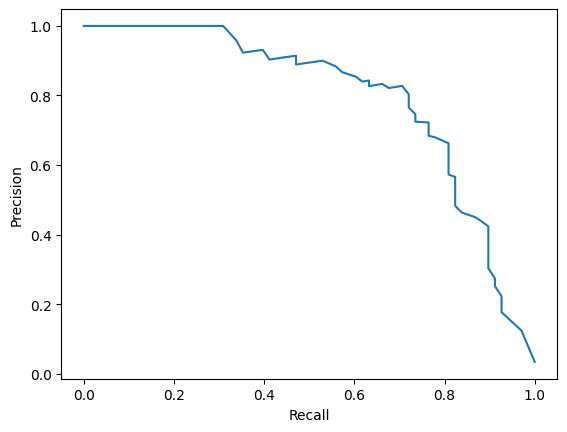

In [16]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

print("accuracy:", accuracy_score(y_test, logreg_pred))
print(classification_report(y_test, logreg_pred, digits=4))
print("average precision score:", average_precision_score(y_test, logreg_proba))
print("precision-recall curve:")
precision, recall, thresholds = precision_recall_curve(y_test, logreg_proba)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()
print("accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, digits=4))
print("average precision score:", average_precision_score(y_test, rf_proba))
print("precision-recall curve:")
precision, recall, thresholds = precision_recall_curve(y_test, rf_proba)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [17]:
logreg_w = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_w.fit(X_train_s, y_train)
logreg_pred = logreg_w.predict(X_test_s)
logreg_proba = logreg_w.predict_proba(X_test_s)[:,1]

rf_w = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_w.fit(X_train_s, y_train)
rf_pred = rf_w.predict(X_test_s)
rf_proba = rf_w.predict_proba(X_test_s)[:,1]

accuracy: 0.8245
              precision    recall  f1-score   support

           0     0.9925    0.8245    0.9008      1932
           1     0.1418    0.8235    0.2419        68

    accuracy                         0.8245      2000
   macro avg     0.5671    0.8240    0.5713      2000
weighted avg     0.9636    0.8245    0.8784      2000

average precision score: 0.38176196610560775
precision-recall curve:


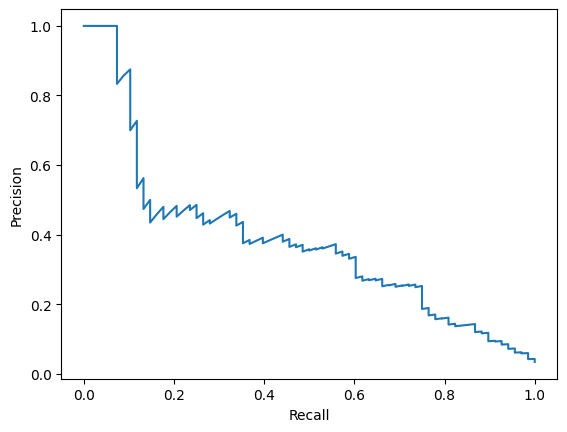

accuracy: 0.98
              precision    recall  f1-score   support

           0     0.9802    0.9995    0.9897      1932
           1     0.9667    0.4265    0.5918        68

    accuracy                         0.9800      2000
   macro avg     0.9734    0.7130    0.7908      2000
weighted avg     0.9797    0.9800    0.9762      2000

average precision score: 0.7642407582429013
precision-recall curve:


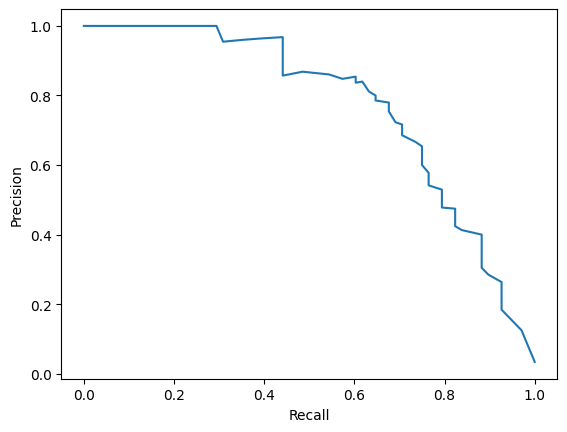

In [19]:
print("accuracy:", accuracy_score(y_test, logreg_pred))
print(classification_report(y_test, logreg_pred, digits=4))
print("average precision score:", average_precision_score(y_test, logreg_proba))
print("precision-recall curve:")
precision, recall, thresholds = precision_recall_curve(y_test, logreg_proba)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()
print("accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, digits=4))
print("average precision score:", average_precision_score(y_test, rf_proba))
print("precision-recall curve:")
precision, recall, thresholds = precision_recall_curve(y_test, rf_proba)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()